In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prefixspan import PrefixSpan
import networkx as nx

In [37]:
df = pd.read_csv("C:/Users/Kishan Pawar/Downloads/Groceries data.csv", encoding='latin1')

In [38]:
df.head()

,Member_number,Date,itemDescription,year,month,day,day_of_week
0,1808,2015-07-21,tropical fruit,2015,7,21,1
1,2552,2015-05-01,whole milk,2015,5,1,4
2,2300,2015-09-19,pip fruit,2015,9,19,5
3,1187,2015-12-12,other vegetables,2015,12,12,5
4,3037,2015-01-02,whole milk,2015,1,2,4


In [39]:
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index(name='items')
list_of_transactions = transactions['items'].tolist()

In [40]:
ps = PrefixSpan(list_of_transactions)
ps.minlen = 4
frequent_patterns = ps.frequent(1)
frequent_patterns.sort(reverse=True)
for support, pattern in frequent_patterns[:10]:
    print(f"Support: {support}, Pattern: {pattern}")

Support: 3, Pattern: ['soda', 'sausage', 'whole milk', 'shopping bags']
Support: 3, Pattern: ['sausage', 'whole milk', 'other vegetables', 'shopping bags']
Support: 3, Pattern: ['bottled beer', 'whole milk', 'whole milk', 'soda']
Support: 2, Pattern: ['whole milk', 'whole milk', 'yogurt', 'other vegetables']
Support: 2, Pattern: ['whole milk', 'whole milk', 'pip fruit', 'whole milk']
Support: 2, Pattern: ['whole milk', 'whole milk', 'newspapers', 'bottled water']
Support: 2, Pattern: ['whole milk', 'whole milk', 'coffee', 'other vegetables']
Support: 2, Pattern: ['whole milk', 'white bread', 'whole milk', 'rolls/buns']
Support: 2, Pattern: ['whole milk', 'pip fruit', 'soda', 'margarine']
Support: 2, Pattern: ['whole milk', 'pastry', 'rolls/buns', 'bottled beer']


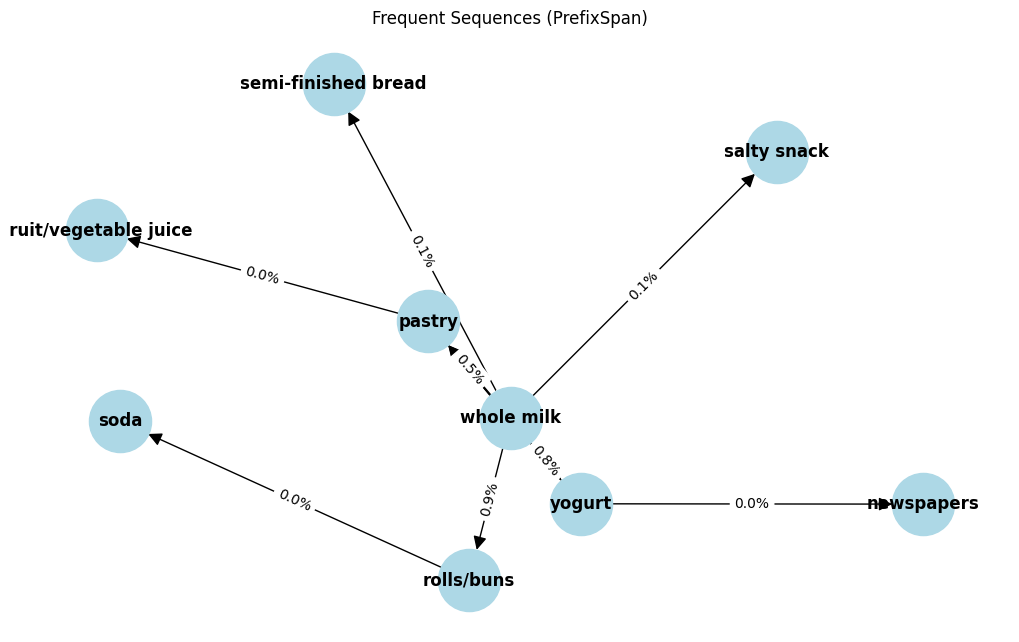

In [41]:
minsup_percentage = 0.0003
minsup_count = int(len(list_of_transactions) * minsup_percentage)
ps = PrefixSpan(list_of_transactions)
ps.minlen = 2
frequent_patterns = ps.frequent(minsup_count)
total_transactions = len(list_of_transactions)
G = nx.DiGraph()
for support, pattern in frequent_patterns[:10]:
    percentage = (support / total_transactions) * 100
    edges = [(pattern[i], pattern[i+1]) for i in range(len(pattern)-1)]
    for edge in edges:
        if G.has_edge(*edge):
            G[edge[0]][edge[1]]["weight"] += percentage
        else:
            G.add_edge(edge[0], edge[1], weight=percentage)
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue",
        font_size=12, font_weight="bold", arrowsize=20)
labels = nx.get_edge_attributes(G, "weight")
labels = {k: f"{v:.1f}%" for k, v in labels.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=10)
plt.title("Frequent Sequences (PrefixSpan)")
plt.show()

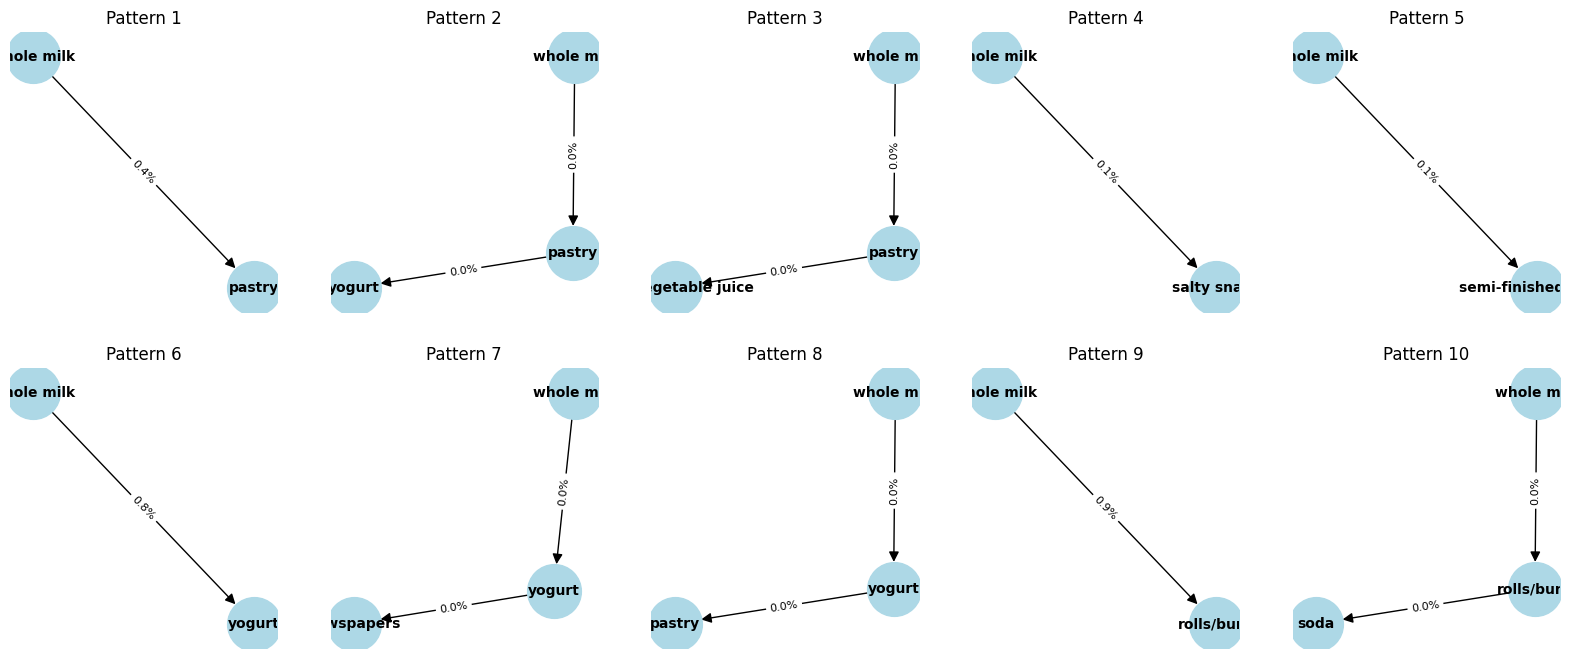

In [42]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))  # for 10 patterns
axes = axes.flatten()

for idx, (support, pattern) in enumerate(frequent_patterns[:10]):
    G = nx.DiGraph()
    percentage = (support / total_transactions) * 100
    edges = [(pattern[i], pattern[i+1]) for i in range(len(pattern)-1)]
    G.add_edges_from(edges, weight=percentage)

    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=1500,
            node_color="lightblue", font_size=10,
            font_weight="bold", arrowsize=15, ax=axes[idx])
    labels = nx.get_edge_attributes(G, "weight")
    labels = {k: f"{v:.1f}%" for k, v in labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=8, ax=axes[idx])
    axes[idx].set_title(f"Pattern {idx+1}")
